# Week 2 — House Price Prediction (Linear Regression)

This section builds a Linear Regression model to predict house prices using 
5 key features: square footage, bedrooms, bathrooms, floors, and condition.

### 1. Load Dataset

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("../data/house_prices.csv")
print(df.shape)
df.head()

(4140, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-09 00:00:00,376000.0,3.0,2.00,1340,1384,3.0,0,0,3,1340,0,2008,0,9245-9249 Fremont Ave N,Seattle,WA 98103,USA
1,2014-05-09 00:00:00,800000.0,4.0,3.25,3540,159430,2.0,0,0,3,3540,0,2007,0,33001 NE 24th St,Carnation,WA 98014,USA
2,2014-05-09 00:00:00,2238888.0,5.0,6.50,7270,130017,2.0,0,0,3,6420,850,2010,0,7070 270th Pl SE,Issaquah,WA 98029,USA
3,2014-05-09 00:00:00,324000.0,3.0,2.25,998,904,2.0,0,0,3,798,200,2007,0,820 NW 95th St,Seattle,WA 98117,USA
4,2014-05-10 00:00:00,549900.0,5.0,2.75,3060,7015,1.0,0,0,5,1600,1460,1979,0,10834 31st Ave SW,Seattle,WA 98146,USA


### 2. Feature Selection

In [19]:
features = ['sqft_living', 'bedrooms', 'bathrooms', 'floors', 'condition']

X = df[features]
y = df['price']

print(X.shape, y.shape)
X.head()

(4140, 5) (4140,)


,sqft_living,bedrooms,bathrooms,floors,condition
0,1340,3.0,2.00,3.0,3
1,3540,4.0,3.25,2.0,3
2,7270,5.0,6.50,2.0,3
3,998,3.0,2.25,2.0,3
4,3060,5.0,2.75,1.0,5


### 3. Train-Test Split & Model Training

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Model trained successfully")

Training set size: (3312, 5)
Test set size: (828, 5)
Model trained successfully


### 4. Model Evaluation (RMSE & R² Score)

In [21]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 267796.00616940105
R² Score: 0.3159307819873852


### 5. Predicted vs Actual Prices (Scatter Plot)

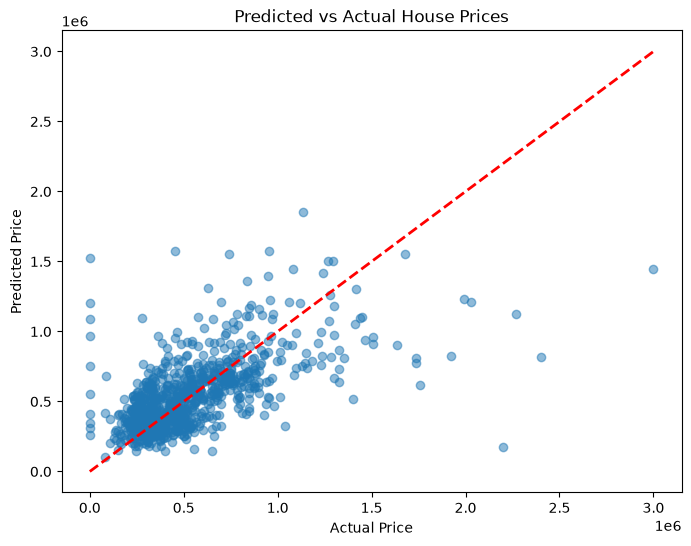

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual House Prices')
plt.show()

### What does the R² score mean?

- Our model's R² score is **0.32**, meaning it can explain about **32%** of the reasons why house prices go up or down, using just square footage, bedrooms, bathrooms, floors, and condition.
- The remaining **68%** is driven by factors we didn't include — most importantly **location** (which city or neighborhood the house is in).
- Houses of the same size can vary hugely in price depending on where they are, which our current model doesn't capture.
- In short, this model gives a **rough starting estimate**, but it shouldn't be relied on for accurate pricing without location data.